In [174]:
import torch
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [185]:
import numpy as np
import torch
# 读取.npy文件
eta00 = np.load('data/1000_1s_data_eta00.npy')
eta = eta00[:-1,1,:]
tensor = torch.tensor(eta)
tensor_transposed = torch.transpose(tensor, 0, 1)

# 添加一个维度，变成形状为 (320, 32, 1) 的张量
tensor_reshaped = torch.unsqueeze(tensor_transposed, -1)

# 打印转换后张量的形状
print(tensor_reshaped.shape)
x = tensor_reshaped[:,:-1,:].float().to('cuda')
y = tensor_reshaped[:,1:,:].float().to('cuda')

torch.Size([320, 999, 1])


In [186]:
import torch.nn as nn
class Net(nn.Module):
    def __init__(self, ):
        super(Net, self).__init__() #调用了父类 nn.Module 的构造函数

        self.rnn = nn.GRU(
            input_size=1,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
        )
        for p in self.rnn.parameters():
            nn.init.normal_(p, mean=0.0, std=0.001)   # 对参数进行初值化

        self.linear = nn.Linear(256, 1)

    def forward(self, x, hidden_prev):
        out, hidden_prev = self.rnn(x, hidden_prev)  # [b, seq, h]
        out = self.linear(out)
        return out, hidden_prev

In [188]:

import torch.optim as optim

model = Net().to('cuda')
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), 0.001)

hidden_prev = torch.zeros(2, 320, 256).to('cuda')

for epoch in range(100):
    output, hidden_prev = model(x, hidden_prev)
    hidden_prev = hidden_prev.detach()
    loss = criterion(output, y)
    model.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print("Iteration:{} loss {}".format(iter, loss.item()))

Iteration:<built-in function iter> loss 0.03020497038960457
Iteration:<built-in function iter> loss 0.02651211805641651
Iteration:<built-in function iter> loss 0.02471105195581913
Iteration:<built-in function iter> loss 0.013024410232901573
Iteration:<built-in function iter> loss 0.00471276743337512
Iteration:<built-in function iter> loss 0.004501571413129568
Iteration:<built-in function iter> loss 0.003162292530760169
Iteration:<built-in function iter> loss 0.0029747483786195517
Iteration:<built-in function iter> loss 0.0029016598127782345
Iteration:<built-in function iter> loss 0.0028174840845167637


In [189]:
tensor_expanded = torch.unsqueeze(y[:,997,:], dim=1)

In [190]:
(pred, hidden_prev) = model(tensor_expanded, hidden_prev)
pred.view(320)
a = pred.cpu().view(320).detach().numpy()

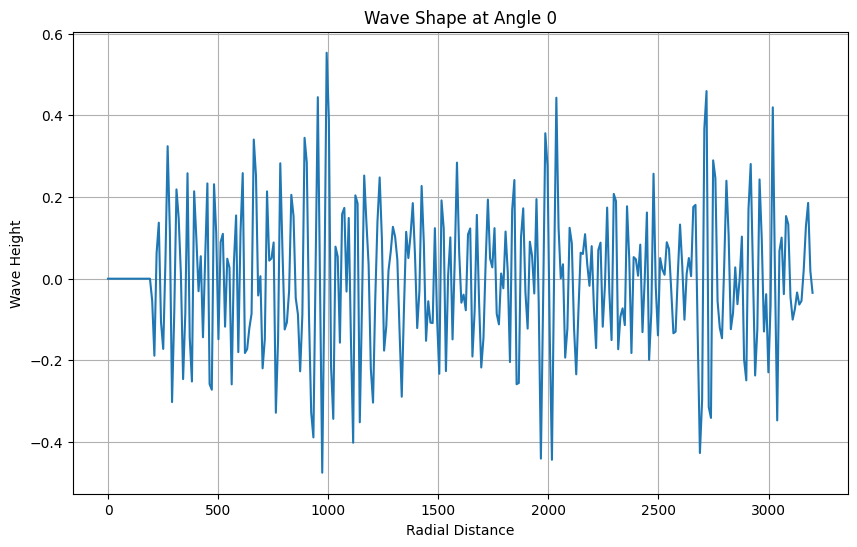

In [192]:
import matplotlib.pyplot as plt

# 选择第一帧数据和第一个角度
frame_index = 999
angle_index = 1
eta_frame = eta00[frame_index]
eta_angle = eta_frame[angle_index]

# 设置径向范围
r_values = np.linspace(0, 3200, 320)

# 可视化波浪形状
plt.figure(figsize=(10, 6))
plt.plot(r_values, eta_angle)
# plt.plot(r_values, a)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()

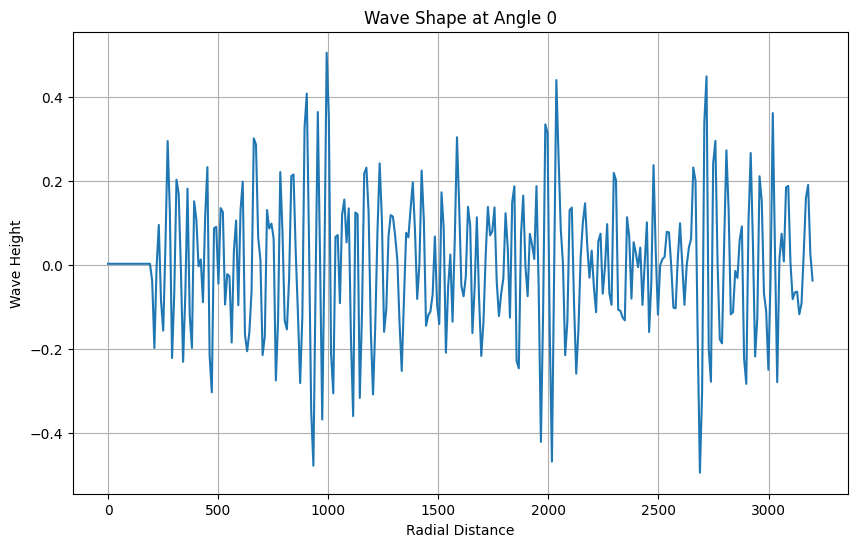

In [195]:
import matplotlib.pyplot as plt

# 选择第一帧数据和第一个角度
frame_index = 999
angle_index = 1
eta_frame = eta00[frame_index]
eta_angle = eta_frame[angle_index]

# 设置径向范围
r_values = np.linspace(0, 3200, 320)

# 可视化波浪形状
plt.figure(figsize=(10, 6))
# plt.plot(r_values, eta_angle)
plt.plot(r_values, a)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()

In [145]:
def seq_data_iter_random(corpus, batch_size, num_steps):  
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

In [147]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):  #@save
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始划分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [149]:
corpus = torch.randn(1000,720,320)
batch_size = 4
num_steps = 100

In [140]:
# Example usage:
# Define model parameters
cnn_channels = 64
rnn_hidden_size = 128
rnn_layers = 2
num_classes = 10

# Create model instance
model = WaveNet(64, 128, 2, 10)

# Example input
batch_size = 32
sequence_length = 100
input_channels = 1
input_data = torch.randn(batch_size, input_channels, sequence_length)

# Forward pass
output = model(input_data)
print("Output shape:", output.shape)

        self.fc = nn.Linear(in_features=cnn_channels, out_features=num_classes)

IndentationError: unexpected indent (436908620.py, line 21)

In [ ]:
output.size()

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size1, kernel_size2, stride1, stride2):
        super(SimpleCNN, self).__init__()
        
        # 第一个卷积层
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=output_channels, kernel_size=kernel_size1, stride=stride1)
        self.relu1 = nn.ReLU()
        
        # 第二个卷积层
        self.conv2 = nn.Conv1d(in_channels=output_channels, out_channels=output_channels, kernel_size=kernel_size2, stride=stride2)
        self.relu2 = nn.ReLU()
        
        # 池化层
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # 全连接层
        self.fc = nn.Linear(output_channels, 10)  # 假设输出维度为10

    def forward(self, x):
        # 第一层卷积 + ReLU
        x = self.relu1(self.conv1(x))
        
        # 池化
        x = self.pool(x)
        
        # 第二层卷积 + ReLU
        x = self.relu2(self.conv2(x))
        
        # 池化
        x = self.pool(x)
        
        # 将特征拉平
        x = x.view(x.size(0), -1)
        
        # 全连接层
        x = self.fc(x)
        return x

# 实例化模型
input_channels = 3  # 输入通道数
output_channels = 16  # 输出通道数
kernel_size1 = 3  # 第一个卷积核大小
kernel_size2 = 3  # 第二个卷积核大小
stride1 = 1  # 第一个卷积步长
stride2 = 1  # 第二个卷积步长
model = SimpleCNN(input_channels, output_channels, kernel_size1, kernel_size2, stride1, stride2)

# 打印模型结构
print(model)
